/kaggle/input 0 files
/kaggle/input/datasets 0 files
/kaggle/input/datasets/rahmasleam 0 files
/kaggle/input/datasets/rahmasleam/intel-image-dataset 0 files
/kaggle/input/datasets/rahmasleam/intel-image-dataset/Intel Image Dataset 0 files
/kaggle/input/datasets/rahmasleam/intel-image-dataset/Intel Image Dataset/mountain 525 files
/kaggle/input/datasets/rahmasleam/intel-image-dataset/Intel Image Dataset/street 501 files
/kaggle/input/datasets/rahmasleam/intel-image-dataset/Intel Image Dataset/buildings 437 files
/kaggle/input/datasets/rahmasleam/intel-image-dataset/Intel Image Dataset/sea 510 files
/kaggle/input/datasets/rahmasleam/intel-image-dataset/Intel Image Dataset/forest 474 files
/kaggle/input/datasets/rahmasleam/intel-image-dataset/Intel Image Dataset/glacier 553 files
['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']
2100 450 450
label
glacier      0.184286
mountain     0.174762
sea          0.170000
street       0.167143
forest       0.158095
buildings    0.1457

I0000 00:00:1784755159.553102      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/30
10/66 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1841 - loss: 2.3458

I0000 00:00:1784755170.068075     125 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.4476 - loss: 1.3988 - val_accuracy: 0.4911 - val_loss: 1.2694
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5805 - loss: 1.0717 - val_accuracy: 0.6178 - val_loss: 0.9903
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6195 - loss: 0.9566 - val_accuracy: 0.6489 - val_loss: 0.9024
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6771 - loss: 0.8265 - val_accuracy: 0.6800 - val_loss: 0.8621
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7286 - loss: 0.6870 - val_accuracy: 0.7378 - val_loss: 0.7755
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7890 - loss: 0.5628 - val_accuracy: 0.7311 - val_loss: 0.8235
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8367 - loss: 0.4353 - val_accuracy: 0.7178 - val_loss: 0.8890
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8890 - loss: 0.3100 - val_accuracy: 0.7133 - val_loss: 0

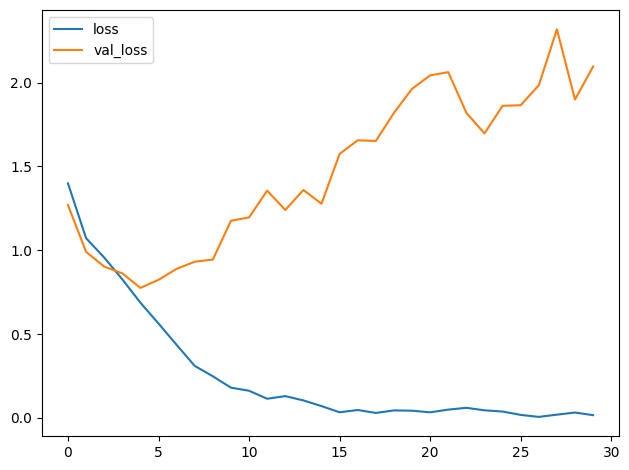

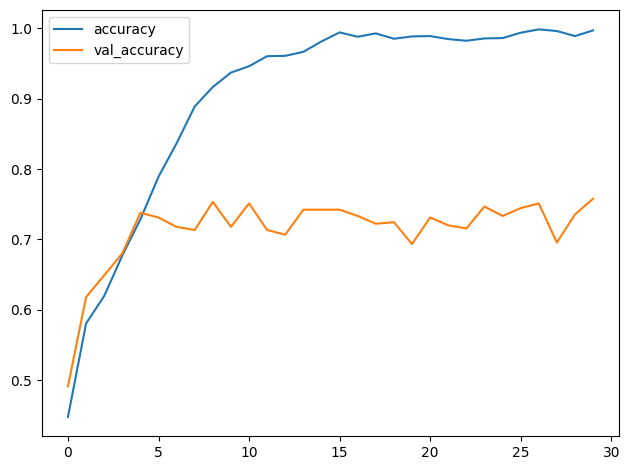

In [1]:
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Reproducibility
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
set_seed()

# Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore")

AUTOTUNE = tf.data.experimental.AUTOTUNE

for dirpath, dirnames, filenames in os.walk('/kaggle/input'):
    print(dirpath, len(filenames), 'files')

base_path = '/kaggle/input/datasets/rahmasleam/intel-image-dataset/Intel Image Dataset'
class_names = os.listdir(base_path)
print(class_names)

import pandas as pd

data = []

for class_name in class_names:
    class_folder = os.path.join(base_path, class_name)
    files = os.listdir(class_folder)
    for filename in files:
        filepath = os.path.join(class_folder, filename)
        data.append({'filepath': filepath, 'label': class_name})

df = pd.DataFrame(data)

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    df['filepath'], df['label'], 
    test_size=0.3, 
    stratify=df['label'],  # <-- This guarantees proportional splitting
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    stratify=y_temp,  # <-- This guarantees proportional splitting
    random_state=42
)

print(len(X_train), len(X_val), len(X_test))
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

class_names = sorted(df['label'].unique())
label_to_index = {name: i for i, name in enumerate(class_names)}
print(label_to_index)

y_train_encoded = y_train.map(label_to_index).values
y_val_encoded = y_val.map(label_to_index).values
y_test_encoded = y_test.map(label_to_index).values

IMG_SIZE = 150

def load_and_preprocess_image(filepath, label):
    image = tf.io.read_file(filepath)               # read the raw file bytes from disk
    image = tf.image.decode_jpeg(image, channels=3)  # turn those bytes into actual pixel values
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])  # force it to be exactly 150x150
    image = tf.cast(image, tf.float32) / 255.0        # scale pixel values from 0-255 down to 0-1
    return image, label

BATCH_SIZE = 32
AUTOTUNE = tf.data.experimental.AUTOTUNE  # you may already have this from your boilerplate

def make_dataset(filepaths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths.values, labels))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths))
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train_encoded, shuffle=True)
val_ds = make_dataset(X_val, y_val_encoded, shuffle=False)
test_ds = make_dataset(X_test, y_test_encoded, shuffle=False)

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    # Block One
    layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same',
                  input_shape=[150, 150, 3]),
    layers.MaxPool2D(),

    # Block Two
    layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPool2D(),

    #Block Three
    layers.Conv2D(filters=128, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPool2D(),

    # Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(6, activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
)

history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot();